##Importing Necessary Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
%matplotlib inline
import tensorflow as tf
import keras
import glob
import cv2
import shutil
import pickle, datetime

from keras.models import Model, Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D,GlobalAveragePooling2D,Lambda
from keras.layers import Input,Convolution2D,Activation
from keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers, activations
from tensorflow.keras.utils import to_categorical
from keras.preprocessing import sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import load_model, Model, Sequential
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, f1_score,precision_recall_curve,multilabel_confusion_matrix,roc_auc_score,roc_curve,auc
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
# Import the backend
from keras import backend as K
import os

##Loading Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
sdir='/content/drive/MyDrive/BrainUltrasound_Multiclass'
categories=['test', 'train', 'valid']
for category in categories:
    category_path=os.path.join(sdir, category)
    filepaths=[]
    labels=[]
    classlist=os.listdir(category_path)
    for klass in classlist:
        classpath=os.path.join(category_path,klass)
        flist=os.listdir(classpath)
        for f in flist :
            if f.endswith('.jpg'):
              fpath=os.path.join(classpath,f)
              filepaths.append(fpath)
              labels.append(klass)
    Fseries=pd.Series(filepaths, name='filepaths')
    Lseries=pd.Series(labels, name='labels')
    if category=='test':
        test_df=pd.concat([Fseries, Lseries], axis=1)
    elif category=='train':
        train_df=pd.concat([Fseries, Lseries], axis=1)
    else:
        valid_df=pd.concat([Fseries, Lseries], axis=1)

print('train_df length: ', len(train_df), ' test_df length: ', len(test_df), '  valid_df length: ', len(valid_df))
print (train_df['labels'].value_counts())

train_df length:  1284  test_df length:  81   valid_df length:  271
labels
normal                       225
mild-ventriculomegaly        187
moderate-ventriculomegaly    178
arachnoid-cyst               114
encephalocele                113
cerebellah-hypoplasia        111
severe-ventriculomegaly      105
polencephaly                  76
colphocephaly                 72
intracranial-hemorrdge        41
anold-chiari-malformation     33
m-magna                       29
Name: count, dtype: int64


Axes(0.125,0.11;0.775x0.77)


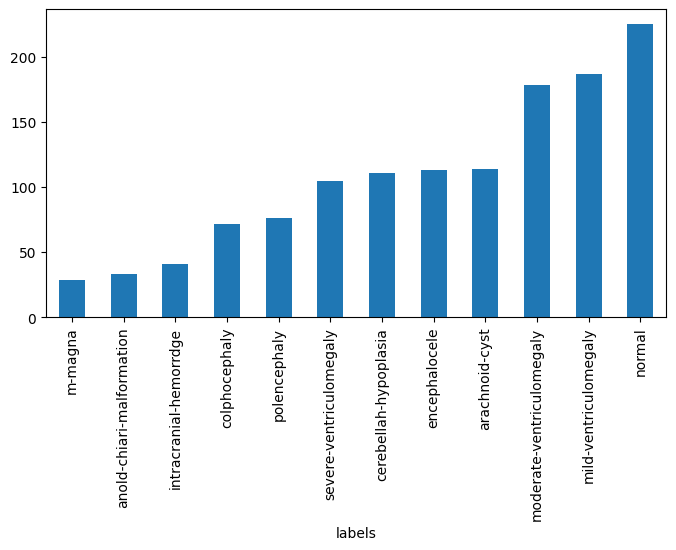

In [ ]:
print (train_df['labels'].value_counts().sort_values().plot(kind = 'bar',figsize=(8,4)))

##Augmentations

In [ ]:
working_dir='/content/drive/MyDrive'
aug_dir=os.path.join(working_dir, 'aug')
if os.path.isdir(aug_dir):
    shutil.rmtree(aug_dir)
os.mkdir(aug_dir)
for label in train_df['labels'].unique():
    dir_path=os.path.join(aug_dir,label)
    os.mkdir(dir_path)
print(os.listdir(aug_dir))

['normal', 'arachnoid-cyst', 'cerebellah-hypoplasia', 'colphocephaly', 'encephalocele', 'anold-chiari-malformation', 'm-magna', 'mild-ventriculomegaly', 'moderate-ventriculomegaly', 'polencephaly', 'severe-ventriculomegaly', 'intracranial-hemorrdge']


In [ ]:
gen=ImageDataGenerator(horizontal_flip=True, vertical_flip=True, rotation_range=90)
groups=train_df.groupby('labels') # group by class
for label in train_df['labels'].unique():  # for every class
    group=groups.get_group(label)  # a dataframe holding only rows with the specified label
    sample_count=len(group)   # determine how many samples there are in this class
    if sample_count<50:
      target= sample_count*3
    elif (50<=sample_count<100):
      target= sample_count*2
    elif (100<=sample_count<150):
      target= int(sample_count*1.5)
    else:
      target=sample_count

    if sample_count< target: # if the class has less than target number of images
        aug_img_count=0
        delta=target-sample_count  # number of augmented images to create
        target_dir=os.path.join(aug_dir, label)  # define where to write the images
        aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=(640,640), class_mode=None, batch_size=1,
                                         shuffle=True, save_to_dir=target_dir, save_prefix='aug-',save_format='jpg')
        while aug_img_count<delta:
            images=next(aug_gen)
            aug_img_count += len(images)

Found 114 validated image filenames.
Found 111 validated image filenames.
Found 72 validated image filenames.
Found 113 validated image filenames.
Found 33 validated image filenames.
Found 29 validated image filenames.
Found 76 validated image filenames.
Found 105 validated image filenames.
Found 41 validated image filenames.


##Combining Training Data with Augmentation Data

In [ ]:
aug_fpaths = []
aug_labels = []
classlist = os.listdir(aug_dir)

for klass in classlist:
    classpath = os.path.join(aug_dir, klass)
    flist = os.listdir(classpath)
    for f in flist:
        fpath = os.path.join(classpath, f)
        aug_fpaths.append(fpath)
        aug_labels.append(klass)

Fseries = pd.Series(aug_fpaths, name='filepaths')
Lseries = pd.Series(aug_labels, name='labels')
aug_df = pd.concat([Fseries, Lseries], axis=1)

print('Length of aug_df: ', len(aug_df))

train_df = pd.concat([train_df, aug_df], axis=0).reset_index(drop=True)

# Shuffle the DataFrame
train_df = train_df.sample(frac=1.0, replace=False, random_state=123).reset_index(drop=True)

print('Length of train_df is: ', len(train_df))
print(train_df['labels'].value_counts())


Length of aug_df:  574
Length of train_df is:  1858
labels
normal                       225
mild-ventriculomegaly        187
moderate-ventriculomegaly    178
arachnoid-cyst               171
encephalocele                169
cerebellah-hypoplasia        166
severe-ventriculomegaly      157
polencephaly                 152
colphocephaly                144
intracranial-hemorrdge       123
anold-chiari-malformation     99
m-magna                       87
Name: count, dtype: int64


Axes(0.125,0.11;0.775x0.77)


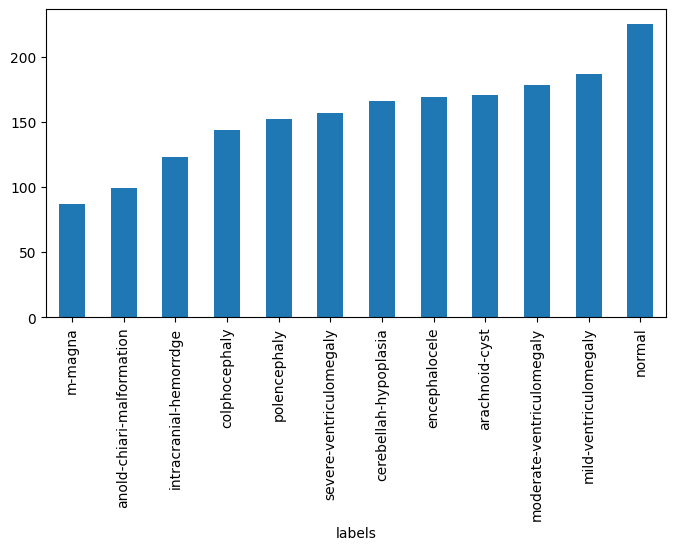

In [ ]:
print (train_df['labels'].value_counts().sort_values().plot(kind = 'bar',figsize=(8,4)))

##Generate Train, Validation, Test Data

In [ ]:
src_path_train='/content/drive/MyDrive/BrainUltrasound_Multiclass/train'
src_path_valid='/content/drive/MyDrive/BrainUltrasound_Multiclass/valid'
src_path_test='/content/drive/MyDrive/BrainUltrasound_Multiclass/test'
train_datagen = ImageDataGenerator( rescale=1.0 / 255.0)
valid_datagen =ImageDataGenerator( rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=src_path_train,
    target_size=(224, 224),
    x_col="filepaths",
    y_col="labels",
    batch_size=8,
    class_mode="categorical",
    shuffle=True,
    seed=42
)
valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=src_path_valid,
    target_size=(224, 224),
    x_col="filepaths",
    y_col="labels",
    batch_size=8,
    class_mode="categorical",
    shuffle=True,
    seed=42
)
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=src_path_test,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    batch_size=1,
    class_mode='categorical',
    shuffle=False,
)

Found 1858 validated image filenames belonging to 12 classes.
Found 271 validated image filenames belonging to 12 classes.
Found 81 validated image filenames belonging to 12 classes.


In [ ]:
train_generator.class_indices

{'anold-chiari-malformation': 0,
 'arachnoid-cyst': 1,
 'cerebellah-hypoplasia': 2,
 'colphocephaly': 3,
 'encephalocele': 4,
 'intracranial-hemorrdge': 5,
 'm-magna': 6,
 'mild-ventriculomegaly': 7,
 'moderate-ventriculomegaly': 8,
 'normal': 9,
 'polencephaly': 10,
 'severe-ventriculomegaly': 11}

##Build Model

In [ ]:
#Instantiate an empty model
model = Sequential()

# 1st Convolutional Layer
model.add(Conv2D(filters=32, input_shape=(224,224,3), kernel_size=(11,11), strides=(4,4), padding="valid"))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

# 2nd Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(11,11), strides=(1,1), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))

# 3rd Convolutional Layer
model.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), padding='valid'))
model.add(Activation('relu'))

# 4th Convolutional Layer
model.add(Conv2D(filters=128, kernel_size=(3,3), strides=(1,1), padding='valid'))
model.add(Activation('relu'))

# 5th Convolutional Layer
model.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='valid'))
model.add(Activation('relu'))
# Max Pooling
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'))
# Passing it to a Fully Connected layer
model.add(Flatten())
# 1st Fully Connected Layer
model.add(Dense(200, input_shape=(224*224*3,)))
model.add(Activation('relu'))
# Add Dropout to prevent overfitting
model.add(Dropout(0.25))

# 2nd Fully Connected Layer
model.add(Dense(100))
model.add(Activation('relu'))
# Add Dropout
model.add(Dropout(0.2))

# 3rd Fully Connected Layer
model.add(Dense(50))
model.add(Activation('relu'))
# Add Dropout
model.add(Dropout(0.1))


# Output Layer
model.add(Dense(12))
model.add(Activation('softmax'))

model.summary()

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, decay=0.0, amsgrad=False),
              metrics=['accuracy'])

# adam = tf.keras.optimizers.Adam(
#     learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False
# )
# model.compile(loss='categorical_crossentropy',
#               optimizer=adam
#               metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)                   │ (None, 54, 54, 32)          │          11,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_54 (Activation)           │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 27, 27, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 17, 17, 64)          │         247,872 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_55 (Activation)           │ (None, 17, 17, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_32 (Conv2D)                   │ (None, 6, 6, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_56 (Activation)           │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_33 (Conv2D)                   │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_57 (Activation)           │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 2, 2, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_58 (Activation)           │ (None, 2, 2, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_20 (MaxPooling2D)      │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 200)                 │          51,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_59 (Activation)           │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 100)                 │          20,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_60 (Activation)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 50)                  │           5,050 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 742,634 (2.83 MB)

 Trainable params: 742,634 (2.83 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


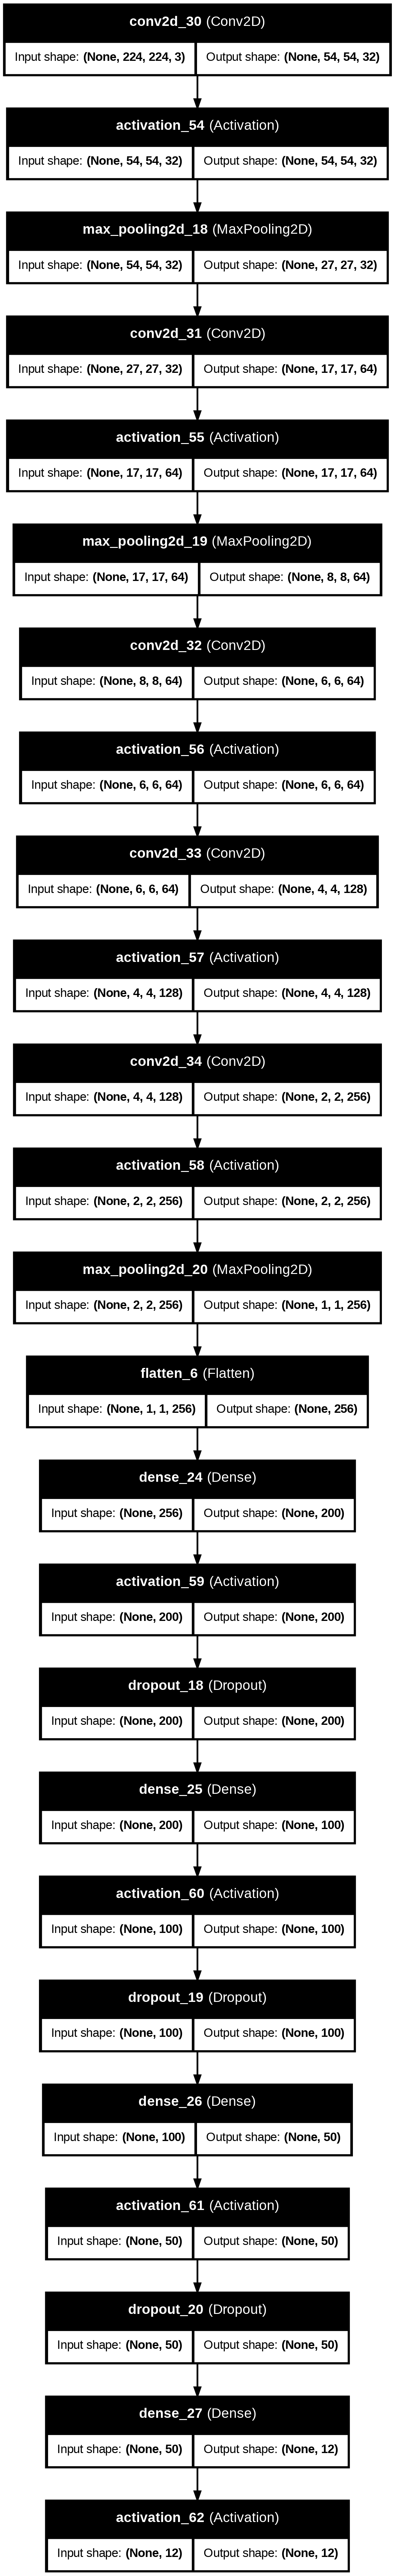

In [ ]:
img_file='/content/drive/MyDrive/mymodel.png'
tf.keras.utils.plot_model(model, to_file=img_file, show_shapes=True,show_layer_names=True)

##Training the model

In [ ]:
hist = model.fit(
    train_generator,
    steps_per_epoch=220,
    epochs=150,
    validation_data=valid_generator,
    validation_steps=30
)

Epoch 1/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.1965 - loss: 2.3064 - val_accuracy: 0.3083 - val_loss: 2.0283
Epoch 2/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1528 - loss: 2.2859 - val_accuracy: 0.3226 - val_loss: 2.0392
Epoch 3/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.2302 - loss: 2.2494 - val_accuracy: 0.3000 - val_loss: 2.0862
Epoch 4/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2719 - loss: 2.1974 - val_accuracy: 0.2258 - val_loss: 2.0326
Epoch 5/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.2292 - loss: 2.2123 - val_accuracy: 0.3750 - val_loss: 1.8843
Epoch 6/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1736 - loss: 2.2718 - val_accuracy: 0.3226 - val_loss: 1.9513
Epoch 7/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.2270 - loss: 2.1842 - val_accuracy: 0.4125 - val_loss: 1.8341
Epoch 8/150
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2597 - loss: 2.1076 - 

##Evaluation Metrics for the model




In [ ]:
plt.plot(hist.history['accuracy'],label="Training accuracy",c='blue')
plt.plot(hist.history['val_accuracy'],label="Validation accuracy",c='orange')
plt.legend()
plt.show()

In [ ]:
plt.plot(hist.history['loss'],label="Training loss",c='blue')
plt.plot(hist.history['val_loss'],label="Validation loss",c='orange')
plt.legend()
plt.show()

In [ ]:
y_prob_pred=model.predict(test_generator)
y_pred = np.argmax(model.predict(test_generator),axis=1)
y_true = np.array(test_generator.labels)

In [ ]:
test_accuracy=accuracy_score(y_true,y_pred)
print(f"Test Accuracy of the model is: {test_accuracy:.2%}")

In [ ]:
class_names=test_generator.class_indices
keysList = list(class_names.keys())
values=list(class_names.values())
class_names

In [ ]:
sns.set(font_scale=1)

In [ ]:
precision=precision_score(y_true,y_pred,average=None)
precision = precision.reshape((12, 1))
plt.figure(figsize=(5,5))
fx=sns.heatmap(precision, annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Precision by Class \n');
fx.set_xlabel('\n Precision\n')
fx.set_ylabel('Classes\n');
fx.yaxis.set_ticklabels(values)
plt.show()

In [ ]:
recall=recall_score(y_true,y_pred,average=None)
recall = recall.reshape((12, 1))
plt.figure(figsize=(5,5))
fx=sns.heatmap(recall, annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Recall by Class \n');
fx.set_xlabel('\n Recall\n')
fx.set_ylabel('Classes\n');
fx.yaxis.set_ticklabels(values)
plt.show()

In [ ]:
y_true_binarized = label_binarize(y_true, classes=values)  # Specify the classes for binarization
n_classes = y_true_binarized.shape[1]

precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_binarized[:, i],
                                                        y_prob_pred[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='{}'.format(keysList[i]))

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower center", prop = { "size": 6 })
plt.title("Precision vs. Recall curve")
plt.show()

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}
# Calculate ROC curve and AUC for each class
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{keysList[i]}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="best", prop = { "size": 8 })
plt.show()

In [ ]:
rac=roc_auc_score(y_true_binarized,y_prob_pred,average='weighted',multi_class='ovr')
print(f"ROC AUC Score of the model is: {rac:.2%}")

In [ ]:
f1=f1_score(y_true,y_pred,average=None)
f1 = f1.reshape((12, 1))
plt.figure(figsize=(5,5))
fx=sns.heatmap(precision, annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('F1 Scores by Class\n');
fx.set_xlabel('\n F1 Score\n')
fx.set_ylabel('Classes\n');
fx.yaxis.set_ticklabels(values)
plt.show()

In [ ]:
c_matrix=confusion_matrix(y_true,y_pred)

In [ ]:
plt.figure(figsize=(30,30))
fx=sns.heatmap(c_matrix, annot=True, fmt=".2f",cmap="GnBu")
fx.set_title('Confusion Matrix \n');
fx.set_xlabel('\n Predicted Values\n')
fx.set_ylabel('Actual Values\n');
fx.xaxis.set_ticklabels(class_names)
fx.yaxis.set_ticklabels(class_names)
plt.show()

In [ ]:
class_report=classification_report(y_true, y_pred,target_names=class_names,output_dict=True)
df = pd.DataFrame(class_report).transpose()
df

##Save Model

In [ ]:
model.save('/content/drive/MyDrive/FB_Model.h5')